### Clean HRRR-AK NetCDF Files

Notebook contents 
* We processed with grib files from folders in `1_process_hrrrak_grib_files` and now we need to do some cleaning and save cleaned netcdfs

created by Cassie Lumbrazo\
last updated: April 2025\
run location: UAS linux\
python environment: **rasterio**

In [4]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [1]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

In [5]:
# load the netcdf 
ds = xr.open_dataset('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_WY2024.nc') 
# ds = xr.open_dataset('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_WY2025.nc') 
ds

<xarray.Dataset> Size: 222MB
Dimensions:       (time: 8784, y: 20, x: 21)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2023-10-01T01:00:00 ... 2024-10-01
    step          (time) timedelta64[ns] 70kB ...
    valid_time    (time) datetime64[ns] 70kB ...
    latitude      (y, x) float64 3kB ...
    longitude     (y, x) float64 3kB ...
Dimensions without coordinates: y, x
Data variables: (12/15)
    temp_surface  (time, y, x) float32 15MB ...
    pressure      (time, y, x) float32 15MB ...
    precip_rate   (time, y, x) float32 15MB ...
    snowdepth     (time, y, x) float32 15MB ...
    orog          (time, y, x) float32 15MB ...
    precip_total  (time, y, x) float32 15MB ...
    ...            ...
    lwrad         (time, y, x) float32 15MB ...
    temp          (time, y, x) float32 15MB ...
    rh            (time, y, x) float32 15MB ...
    u10           (time, y, x) float32 15MB ...
    v10           (time, y, x) float32 15MB ...
    wind          (time, y, x) float32 15MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

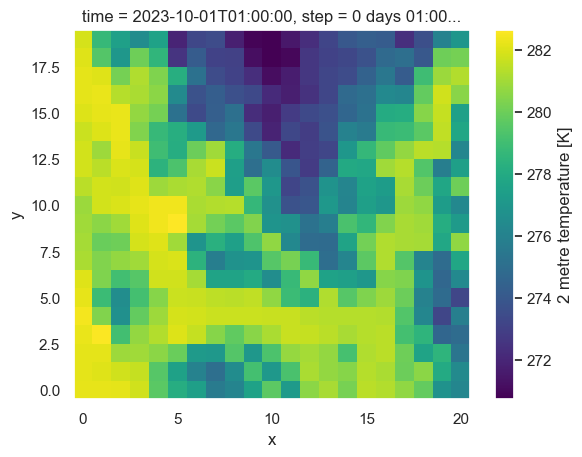

In [6]:
ds.temp[0].plot()

Assign a CRS, and select Powder Patch Gridcell

In [7]:
# Assign latitude and longitude as coordinates for y and x axes
ds = ds.assign_coords({"y": ds.latitude[:, 0], "x": ds.longitude[0, :]})

# Now, check the coordinates again to make sure they are assigned properly
print(ds.coords)

# Now assign the CRS with EPSG:4326 (assuming the lat/lon are in degrees)
ds.rio.write_crs("EPSG:4326", inplace=True)

ds.rio.crs

# Powder Patch Lat/Lon
lat_powderpatch = 58.26200
lon_powderpatch = -134.51700

# select the nearest grid point to the given lat/lon
ds_powderpatch = ds.sel(y=lat_powderpatch, x=lon_powderpatch, method='nearest') 

Coordinates:
  * time        (time) datetime64[ns] 70kB 2023-10-01T01:00:00 ... 2024-10-01
    step        (time) timedelta64[ns] 70kB ...
    valid_time  (time) datetime64[ns] 70kB ...
    latitude    (y, x) float64 3kB ...
    longitude   (y, x) float64 3kB ...
  * y           (y) float64 160B 58.08 58.11 58.14 58.16 ... 58.54 58.56 58.59
  * x           (x) float64 168B 225.1 225.1 225.2 225.2 ... 226.0 226.0 226.1


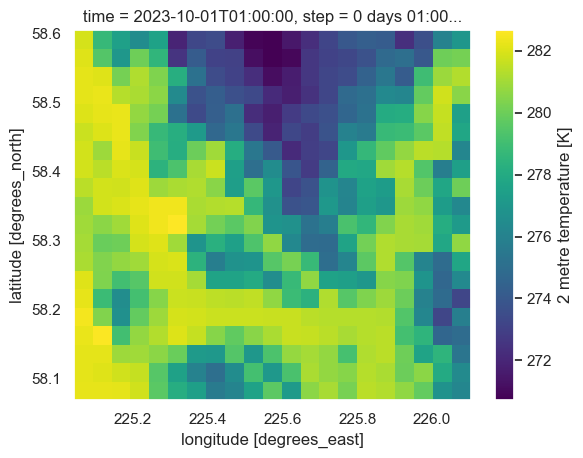

In [8]:
ds.temp[0].plot()

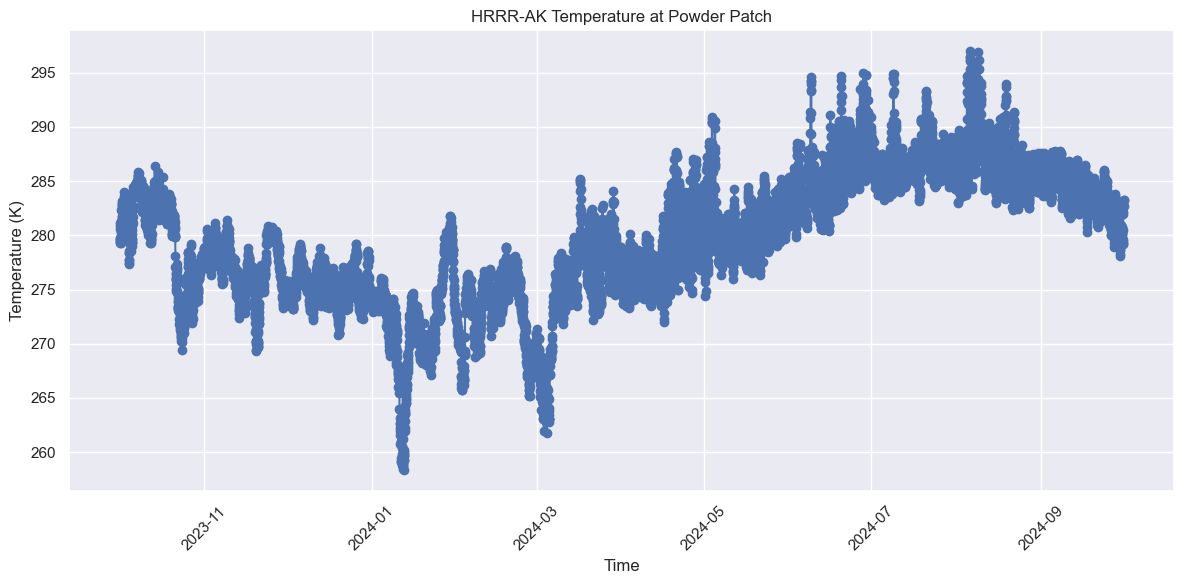

In [10]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_powderpatch['valid_time'].values, ds_powderpatch['temp'].values, marker='o', linestyle='-', color='b')
plt.title('HRRR-AK Temperature at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Temperature (K)')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

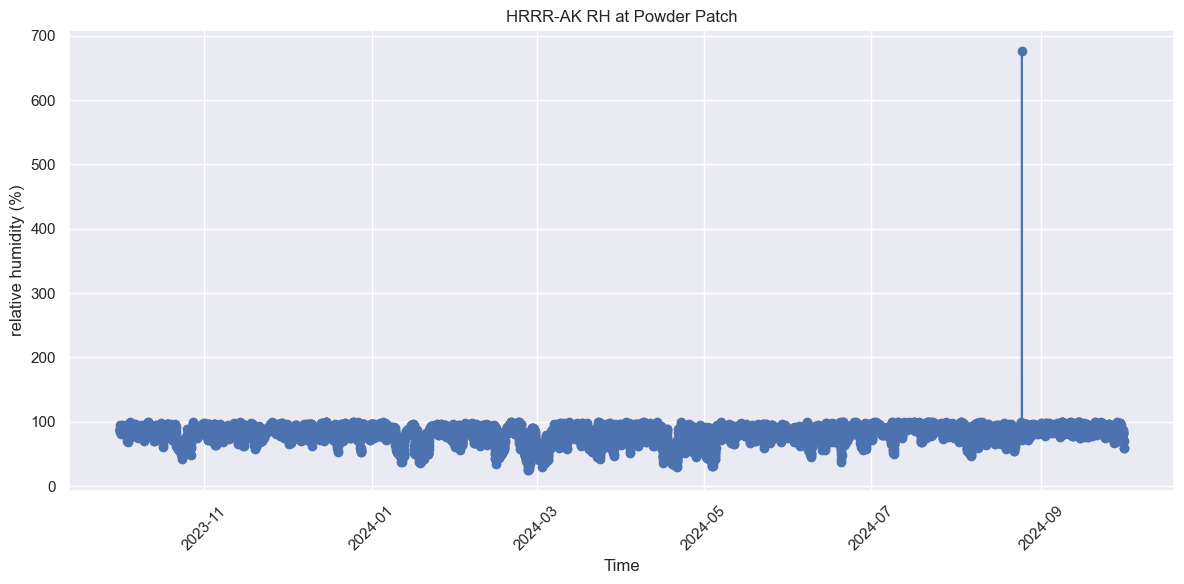

In [11]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_powderpatch['valid_time'].values, ds_powderpatch['rh'].values, marker='o', linestyle='-', color='b')
plt.title('HRRR-AK RH at Powder Patch')
plt.xlabel('Time')
plt.ylabel('relative humidity (%)')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()